# So in clear terms, what I'm trying to do is a machine learning pipeline that automatically identifies whether a mutating strain of the Influenza A virus is adapted to infect Humans or restricted to Avian (Bird) hosts.
# So I will be using genomic data from an infected human and an avian host.

In [ ]:
#installing biopython
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.0 MB/s eta 0:00:00


In [ ]:
#getting other libraries ready

from Bio import Entrez
from Bio import SeqIO
from Bio.Seq import Seq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import os


In [ ]:
#setting my email for NCBI's Entrez
Entrez.email = "etinilevi0@gmail.com"

**This is like Step 1, so here we are basically downloading, reading and writing the sequence from NCBI straight.**

In [ ]:
#Let's download the influenza genetic data from NCBI straight from here
def download_influenza_data():
  output_filename = "ncbi_influenza_data.fasta"
#this will be our search terms
  queries = {
      "Human": 'Influenza A virus[Organism] AND HA [Gene] AND Human[Host] AND "complete cds" [Title]',
      "Avian": 'Influenza A virus[Organism] AND HA [Gene] AND Avian[Host] AND "complete cds"[Title]'
  }
#we need 2,500 sequences from each of them
  sequences_per_group = 2500

#opening up my local storage to save the sequences
  with open(output_filename, 'w') as Files:
    for host_label, search_string in queries.items():
      #let's search the db to get a list of their accession number
      search_handle = Entrez.esearch(db="nucleotide", term=search_string, retmax=sequences_per_group)
      search_results = Entrez.read(search_handle)
      search_handle.close()

      id_list = search_results["IdList"]
      print(f"The number of sequences matched our criteria was {len(id_list)}")

      #now that we have done that, lets fetch the actual FASTA text using the IDs
      if id_list:
        fetch_handle = Entrez.efetch(db="nucleotide", id=",".join(id_list), rettype="fasta", retmode="text")

      #lets read and write the text from the internet
      raw_fasta_data = fetch_handle.read()
      fetch_handle.close()

      #lets add headers to make it easier to view
      modified_fasta_data = ""
      for line in raw_fasta_data.splitlines():
        if line.startswith(">"):
          modified_fasta_data += f"{line}_HOST_{host_label}\n"
        else:
          modified_fasta_data += f"{line}\n"

      Files.write(modified_fasta_data)
      print(f"We have successfully downloaded {host_label} sequences.")



download_influenza_data()






The number of sequences matched our criteria was 2500
We have successfully downloaded Human sequences.
The number of sequences matched our criteria was 2500
We have successfully downloaded Avian sequences.


**This is the Step 2. Here we are basically trying to clean the data we have gotten. Like a quality control**

In [ ]:
#lets open a new function so we can parse the data, do the translation, and fliter the sequences
def quality_control(input_fasta):
  cleaned_records = []

  for record in SeqIO.parse(input_fasta, "fasta"):
  # grabbing the raw sequence
    nucleotide_seq = record.seq

  #doing translation (nucleotide to amino acid)
    protein_seq = str(nucleotide_seq.translate(to_stop=True)).upper()

    header = record.description

  #lets extract the host label and lable human and aves as 1 and 0 respecitively
    if "_HOST_Human" in header:
      host_label = 1
    elif "_HOST_Avian" in header:
      host_label = 0
    else:
      continue

    cleaned_records.append({
        "Accession_ID": record.id,
        "Sequence": protein_seq,
        "Length": len(protein_seq),
        "Label": host_label
    })

  df_raw = pd.DataFrame(cleaned_records)
  print(f"The total sequence found is {len(df_raw)}")
  print(f"The median length of the protein after translation is {df_raw['Length'].median()}")

  #the next thing to do now is apply filters on the protein length
  min_cutoff = 500
  max_cutoff = 650

  df_filtered = df_raw[(df_raw["Length"] >= min_cutoff) & (df_raw["Length"] <= max_cutoff)]
  dropped_by_length = len(df_raw) - len(df_filtered)
  print(f"The number of sequences dropped by length is {dropped_by_length}")

  #lets look for unreadable machine letters
  df_clean = df_filtered[~df_filtered["Sequence"].str.contains("X")]
  dropped_by_corruption = len(df_filtered) - len(df_clean)
  print(f"The number of sequences dropped by corruption is {dropped_by_corruption}")

  #lets remove exact duplicates
  df_final = df_clean.drop_duplicates(subset=["Sequence"]).reset_index(drop=True)
  dropped_by_duplicates = len(df_clean) - len(df_final)
  print(f"The number of sequences dropped by duplicates is {dropped_by_duplicates}")

  print(df_final["Label"].value_counts().rename({1: "1 (Human-Adapted)", 0: "0 (Avian-Restricted)"}))

  return df_final

df_clean_influenza = quality_control("ncbi_influenza_data.fasta")
df_clean_influenza.head()






/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


The total sequence found is 5000
The median length of the protein after translation is 560.0
The number of sequences dropped by length is 1742
The number of sequences dropped by corruption is 440
The number of sequences dropped by duplicates is 1689
Label
0 (Avian-Restricted)    615
1 (Human-Adapted)       514
Name: count, dtype: int64


,Accession_ID,Sequence,Length,Label
0,PZ486205.1,MKAIIALSNILCLVFAQNIPGNDNSTATLCLGHHAVPNGTIVKTIT...,566,1
1,PZ486204.1,MKAIIALSNILCLVFAQNIPGNDNSTATLCLGHHAVPNGTIVKTIT...,566,1
2,PZ486203.1,MKAIIALSNILCLVFAQNIPGNDNSTATLCLGHHAVPNGTIVKTIT...,566,1
3,PZ486202.1,MKAIIALSNILCLVFAQNIPGNDNSTATLCLGHHAVPNGTIVKTIT...,566,1
4,PZ486201.1,MKAIIALSNILCLVFAQNIPGNDNSTATLCLGHHAVPNGTIVKTIT...,566,1


**In the next step, we will be doing *feature engineering*.
Basically, we will use Kmer; K = 3. After getting that, we will convert them into numpy arraw.**

In [ ]:
#let's create a function to handle it
def extract_real_features(df, k=3):
  def get_sequence_kmers(seq, k_size):
    return [seq[i:i+k_size] for i in range(len(seq) - k_size + 1)]

  #lets extract and compile a master vocabulary of all unique k-mers present in the data
  global_vocab = set()
  for seq in df["Sequence"]:
    global_vocab.update(get_sequence_kmers(seq, k))

  sorted_vocab = sorted(list(global_vocab))
  print(f"The length of the vocabulary is {len(sorted_vocab)}")

  #lets build the numerical matrix X row by row
  matrix_rows = []

  for seq in df['Sequence']:
    #counting the 3-mers for specific sequence
    sequence_counts = collections.Counter(get_sequence_kmers(seq, k))

    #match the counts against the global sorted vocab layout
    vector_row = [sequence_counts.get(kmer, 0) for kmer in sorted_vocab]
    matrix_rows.append(vector_row)

  #Converting everything into numpy arrays
  X = np.array(matrix_rows)
  y = df["Label"].values

  return X, y, sorted_vocab

X, y, influenza_vocab = extract_real_features(df_clean_influenza, k=3)
print(X.shape)
print(y.shape)







The length of the vocabulary is 5086
(1129, 5086)
(1129,)


# The next step now is Machine Learning.
## Here, we will be using Random Forest Model to train and use the data for prediction**

The shape of the X train dataset is 903, and the shape of the X test dataset is 226
The accuracy of the model is 98.672566%
              precision    recall  f1-score   support

    Avian(0)       1.00      0.98      0.99       126
   Human (1)       0.97      1.00      0.99       100

    accuracy                           0.99       226
   macro avg       0.99      0.99      0.99       226
weighted avg       0.99      0.99      0.99       226



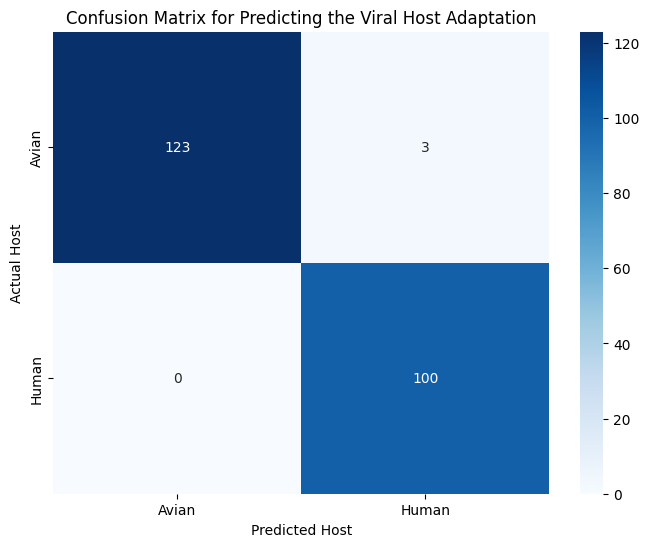

In [ ]:
#let's import all the necessary libraries from sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#let's split 80& for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"The shape of the X train dataset is {X_train.shape[0]}, and the shape of the X test dataset is {X_test.shape[0]}")

#let's train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#let's make predictions
y_pred = rf_model.predict(X_test)

#let's evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"The accuracy of the model is {accuracy * 100:2f}%")

Classification_report = classification_report(y_test, y_pred, target_names=["Avian(0)", "Human (1)"])
print(Classification_report)

#let's visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Avian", "Human"], yticklabels=["Avian", "Human"])
plt.xlabel('Predicted Host')
plt.ylabel('Actual Host')
plt.title('Confusion Matrix for Predicting the Viral Host Adaptation')
plt.show()

**From the ML model, we can see that out model had a 98.67 accuracy and 0.99 F1 score (which is very good). We can also see our True Positive and True Negative from the confusion matrix.**

# So let's move to the last step of this project.
Here, we will idenitfing the top 3-mers; amino acid sequence.**

Kmer_Motif  Importance_Score
       MKA          0.031667
       VRD          0.031446
       ALL          0.023426
       WTG          0.022621
       TLC          0.022097
       FNW          0.018691
       ISF          0.017079
       RVQ          0.015141
       QKG          0.014049
       TGN          0.013732


/tmp/ipykernel_2138/3943156029.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Kmer_Motif', data=kmer_importance_df.head(10), palette='viridis')


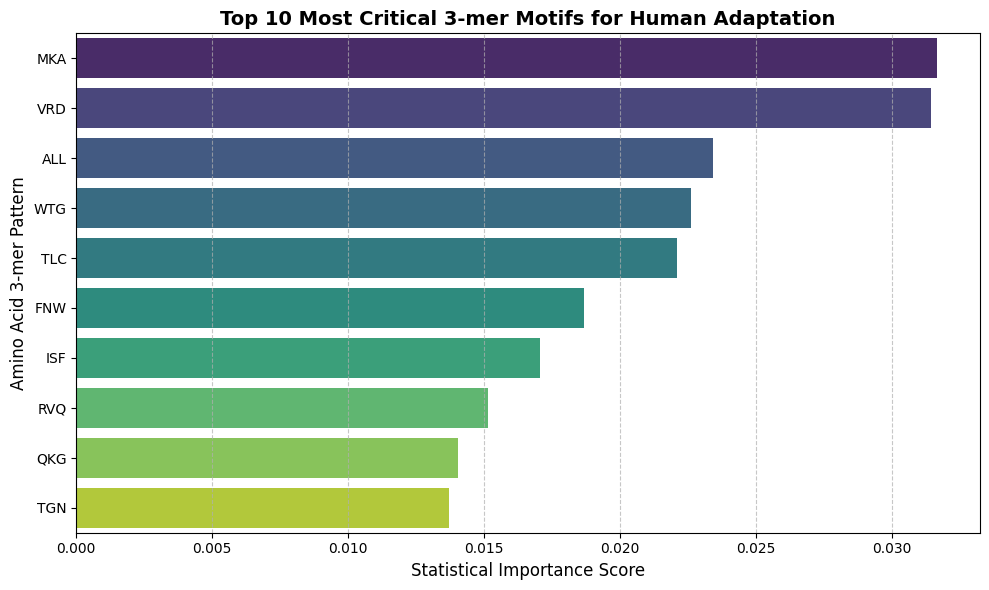

In [ ]:
# let's extract the importance scores for all 5086 features
importances = rf_model.feature_importances_

#let's pair them with their 3-mer names from the vocab
kmer_importance_df = pd.DataFrame({
    'Kmer_Motif': influenza_vocab,
    'Importance_Score': importances
})

#let's sort them from highest to lowest importance\
kmer_importance_df = kmer_importance_df.sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)
print(kmer_importance_df.head(10).to_string(index=False))

#let's do a bar chart for it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Score', y='Kmer_Motif', data=kmer_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Critical 3-mer Motifs for Human Adaptation', fontsize=14, fontweight='bold')
plt.xlabel('Statistical Importance Score', fontsize=12)
plt.ylabel('Amino Acid 3-mer Pattern', fontsize=12)
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## **From this last step, we can see the top 10 amino acid sequences.**
## Our top 3 are:
# *MKA* - Methionine-Lysine-Alanine
# *VRD*- Valine-Arginine-Aspartic Acid
# *ALL*- Alanine-Leucine-Leucine